# Part 10 — Capstone: build your strategy-selection agent end to end

You now have every piece. The capstone asks you to assemble them **on your own data** into a
project you could defend in front of a sceptical portfolio manager.

## The brief
> Build an agent that, at each decision date, chooses one of **your** 7 option strategies (or
> no trade) from market conditions, and show with an honest evaluation whether it beats
> (a) the best single strategy and (b) a simple rule, after costs, out of sample.

## Milestones, deliverables and acceptance criteria

| # | Milestone | Deliverable | Done when… |
|---|---|---|---|
| 1 | **Data** (Part 9) | `market_daily.csv`, `strategy_pnl.csv`, validation report | `validate_inputs` warnings all explained; truncation test passes (Part 6.2) |
| 2 | **Exploration** (Part 0) | P&L-by-condition heatmap, like Part 0's by-regime chart, using observable buckets | you can state in words which strategy tends to win where |
| 3 | **Baselines** (Part 8.1) | no-trade, best-single-on-train, your own rule, random | a scorecard table |
| 4 | **Contextual bandit** (Part 3) | ridge/LinUCB selector with shadow P&L | walk-forward results plus coefficient sanity check |
| 5 | **Decide: bandit or MDP?** (Part 4.5) | a paragraph using the checklist | explicit reasoning about holding periods, costs, carry-over |
| 6 | **Environment** (Part 6) | Gym env (`PnLTableEnv`, or your own with repricing) | `check_env` plus all sanity tests pass |
| 7 | **Deep RL agent** (Part 7) | PPO and/or DQN with validation-based checkpointing | train/val/test curves; ≥ 3 seeds |
| 8 | **Evaluation** (Part 8) | walk-forward, bootstrap CI, best-of-N note, stress tests | a one-page verdict: skill, luck, or unclear |
| 9 | **Iteration log** (Part 9) | `experiments.csv` with ≥ 6 single-change experiments | every row has a hypothesis |
| 10 | **Final test and deployment plan** | one-time test result, kill switch, monitoring plan | written *before* looking at the test result |

## Grading rubric (self-assessment)

| Criterion | Weak | Strong |
|---|---|---|
| Data hygiene | features computed on full history; costs ignored | truncation test, train-only normalisation, realistic costs, stressed ×2 |
| Baselines | only "vs no trade" | best-single *and* a sensible rule, same costs |
| Evaluation | one split, one seed | walk-forward, ≥ 3 seeds, bootstrap CI, best-of-N awareness |
| Interpretability | "the network decided" | coefficients / selection heatmaps / Monday-scenario explanations that make economic sense |
| Honesty | "Sharpe 3.1!" | "Sharpe 0.9 [0.2, 1.6], beats best single in 7/10 years, edge disappears at 3× costs" |

---
## Reference implementation
Below is a compact, working version of the whole pipeline on the example data from Part 9.
**Use it as a template.** Replace the files, rerun, then extend it through the milestones.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os, json, time
import optrl
from optrl import metrics as M
from optrl.data import build_features, load_market_csv, load_pnl_csv, validate_inputs, align, FEATURES
from gymnasium.utils.env_checker import check_env
M.set_style()

if not os.path.exists("data/strategy_pnl.csv"):          # create the example files if Part 9 wasn't run
    os.makedirs("data", exist_ok=True)
    sim = optrl.load_default_market()
    sim.df[["close", "vix", "vix3m"]].rename_axis("date").to_csv("data/market_daily.csv")
    pd.Series(sim.df.index[sim.df.is_earnings], name="date").to_csv("data/earnings_dates.csv", index=False)
    names = {n: f"strategy_{i + 1}" for i, n in enumerate(optrl.STRATEGY_NAMES)}
    optrl.weekly_pnl_table(sim).drop(columns="no_trade").rename(columns=names).to_csv("data/strategy_pnl.csv")

# ---------------- Milestone 1: data
mkt = load_market_csv("data/market_daily.csv")
earn = pd.read_csv("data/earnings_dates.csv", parse_dates=["date"])["date"] if os.path.exists("data/earnings_dates.csv") else None
X, R = align(build_features(mkt.close, mkt.vix, mkt.vix3m, earn), load_pnl_csv("data/strategy_pnl.csv"))
ACT = list(R.columns)
print(f"{len(X)} decision dates | actions: {ACT}")

# ---------------- chronological split: 55% fit | 15% validation | 30% test (locked)
n = len(X); i_val, i_test = int(n * 0.55), int(n * 0.70)
fit_X, fit_R = X.iloc[:i_val], R.iloc[:i_val]
val_X, val_R = X.iloc[i_val:i_test], R.iloc[i_val:i_test]
dev_X, dev_R = X.iloc[:i_test], R.iloc[:i_test]
test_X, test_R = X.iloc[i_test:], R.iloc[i_test:]
print("fit →", fit_X.index[-1].date(), "| val →", val_X.index[-1].date(), "| test →", test_X.index[-1].date())

995 decision dates | actions: ['no_trade', 'strategy_1', 'strategy_2', 'strategy_3', 'strategy_4', 'strategy_5', 'strategy_6', 'strategy_7']
fit → 2016-09-12 | val → 2019-07-22 | test → 2025-04-14


### Milestone 2: which strategy wins where? (observable buckets only)

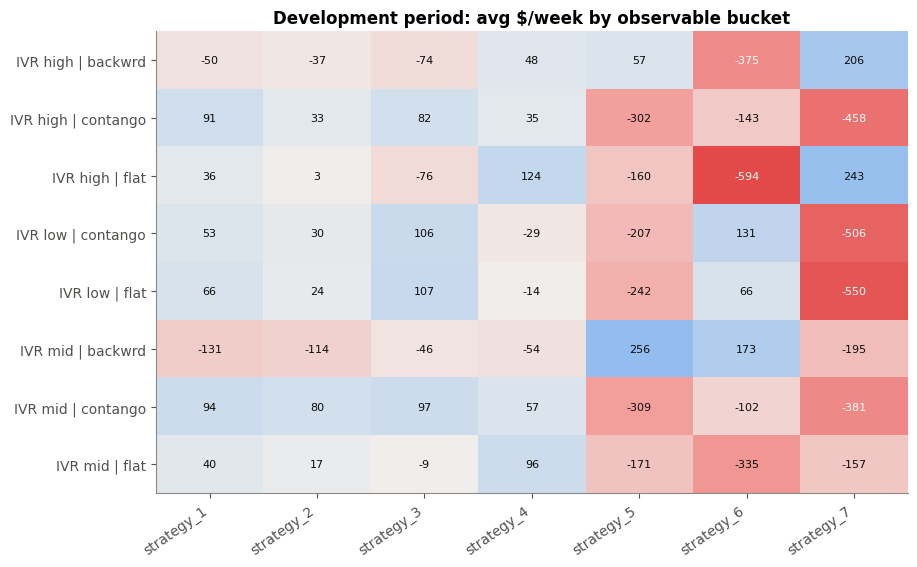

IVR high | backwrd      75
IVR high | contango     14
IVR high | flat         64
IVR low | contango     293
IVR low | flat          50
IVR mid | backwrd       26
IVR mid | contango     106
IVR mid | flat          68


In [2]:
bucket = (pd.cut(dev_X.iv_rank, [-1, 25, 50, 101], labels=["IVR low", "IVR mid", "IVR high"]).astype(str) + " | " +
          pd.cut(dev_X.term_structure, [0, 0.92, 1.0, 9], labels=["contango", "flat", "backwrd"]).astype(str))
heat = dev_R.groupby(bucket).mean().drop(columns="no_trade")
heat["n weeks"] = dev_R.groupby(bucket).size()
M.plot_value_heatmap(heat.drop(columns="n weeks"), "Development period: avg $/week by observable bucket")
plt.show()
print(heat["n weeks"].to_string())

### Milestones 3–4: baselines and the contextual-bandit selector

In [3]:
SWITCH_COST = 25.0
def realized(choices, Rm):
    c = np.asarray(choices); p = Rm.values[np.arange(len(c)), c]
    return p - SWITCH_COST * (np.r_[False, c[1:] != c[:-1]] & (c != 0))

def ridge_fit(Xtr, Rtr, lam=1.0, risk_lambda=0.5):
    mu, sd = Xtr.mean(), Xtr.std()
    Z = np.c_[np.ones(len(Xtr)), ((Xtr - mu) / sd).clip(-5, 5).values]
    y = Rtr.values / 1000; y = y - risk_lambda * y ** 2
    W = np.linalg.solve(Z.T @ Z + lam * np.eye(Z.shape[1]), Z.T @ y)
    return lambda Xm: np.c_[np.ones(len(Xm)), ((Xm - mu) / sd).clip(-5, 5).values] @ W

def ridge_choices(pred, threshold=0.05):
    out, cur = [], 0
    for p in pred:
        b = int(np.argmax(p)); b = cur if (b != cur and p[b] - p[cur] < threshold) else b
        out.append(b); cur = b
    return np.array(out)

def rule(Xm):                                          # YOUR rule goes here (this is Part 1's)
    return np.where(Xm.term_structure > 1.0, ACT.index("strategy_7"), ACT.index("strategy_3"))

best_single = int(dev_R.mean().values.argmax())
candidates = {
    "no_trade": np.zeros(len(test_X), int),
    f"best single ({ACT[best_single]})": np.full(len(test_X), best_single),
    "rule": rule(test_X),
    "ridge selector (risk-aware, threshold)": ridge_choices(ridge_fit(dev_X, dev_R)(test_X)),
}

### Milestones 5–7: MDP environment + PPO (switching costs make it an MDP)
`PnLTableEnv` turns your table into a Gym env: the state includes your last action, and
changing strategy costs `switch_cost`. We select the checkpoint on the validation block and
train 3 seeds.

In [4]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

obs_stats = (fit_X.mean().values, fit_X.std().values)
env = optrl.PnLTableEnv(fit_X, fit_R, switch_cost=SWITCH_COST, obs_stats=obs_stats, seed=0)
check_env(env, skip_render_check=True); print("PnLTableEnv passes check_env ✓")

def train_ppo(seed, steps=60_000, risk=0.0):
    vec = make_vec_env(lambda: optrl.PnLTableEnv(fit_X, fit_R, switch_cost=SWITCH_COST, obs_stats=obs_stats, seed=seed),
                       n_envs=4, seed=seed)
    val_env = Monitor(optrl.PnLTableEnv(val_X, val_R, switch_cost=SWITCH_COST, obs_stats=obs_stats,
                                        episode_len=len(val_X) - 1, random_start=False))
    cb = EvalCallback(val_env, n_eval_episodes=1, eval_freq=2_500, deterministic=True,
                      best_model_save_path=f"models/capstone_ppo_s{seed}", verbose=0)
    PPO("MlpPolicy", vec, seed=seed, verbose=0, n_steps=256, batch_size=256, gamma=0.9, ent_coef=0.01,
        policy_kwargs=dict(net_arch=[64, 64])).learn(steps, callback=cb)
    return PPO.load(f"models/capstone_ppo_s{seed}/best_model")

def ppo_choices(model, Xm, Rm):
    e = optrl.PnLTableEnv(Xm, Rm, switch_cost=SWITCH_COST, obs_stats=obs_stats, episode_len=len(Xm) - 1, random_start=False)
    obs, _ = e.reset(); ch = []
    for _ in range(len(Xm) - 1):
        a = int(model.predict(obs, deterministic=True)[0]); ch.append(a)
        obs, *_ = e.step(a)
    return np.array(ch + [ch[-1]])

t0 = time.time()
for s in [0, 1, 2]:
    candidates[f"PPO seed {s}"] = ppo_choices(train_ppo(s), test_X, test_R)
print(f"PPO x3 trained in {time.time() - t0:.0f}s")

PnLTableEnv passes check_env ✓


PPO x3 trained in 46s


### Milestone 8: the one-page verdict

In [5]:
test_pnl = {k: pd.Series(realized(v, test_R), index=test_X.index) for k, v in candidates.items()}
card = pd.DataFrame({k: M.summarize(v.values) for k, v in test_pnl.items()}).T
card["switches/yr"] = [(np.diff(v) != 0).sum() / (len(v) / 52) for v in candidates.values()]
bench = test_pnl[f"best single ({ACT[best_single]})"].values
def boot_p(x, block=8, n_boot=3000, seed=0):
    rng = np.random.default_rng(seed); n_ = len(x); nb = int(np.ceil(n_ / block))
    idx = ((rng.integers(0, n_, (n_boot, nb))[:, :, None] + np.arange(block)).reshape(n_boot, -1)[:, :n_]) % n_
    return (x[idx].mean(1) > 0).mean()
card["P(beats best single)"] = [np.nan if k.startswith("best single") else boot_p(v.values - bench) for k, v in test_pnl.items()]
print("LOCKED TEST PERIOD:"); card.round(2)

LOCKED TEST PERIOD:


,total_pnl,mean_per_period,sharpe,max_drawdown,cvar_5%,win_rate,switches/yr,P(beats best single)
no_trade,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.01
best single (strategy_3),14052.86,47.00,1.10,4165.01,-931.34,0.81,0.00,NaN
rule,25304.50,84.63,1.11,3856.58,-1069.91,0.79,6.43,0.87
"ridge selector (risk-aware, threshold)",22061.58,73.78,1.98,2332.61,-944.34,0.88,7.30,0.91
PPO seed 0,18753.45,62.72,0.44,8680.56,-1098.14,0.55,18.26,0.59
PPO seed 1,-3306.36,-11.06,-0.08,17218.79,-1091.57,0.50,10.26,0.19
PPO seed 2,16484.85,55.13,0.54,5257.90,-1096.41,0.72,13.57,0.56


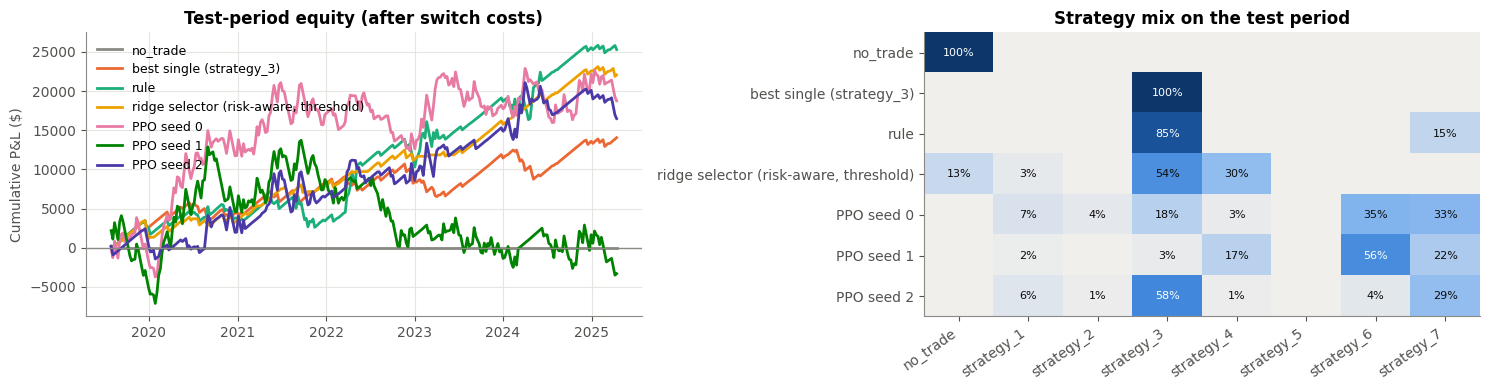

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
M.plot_equity(test_pnl, title="Test-period equity (after switch costs)", ax=axes[0])
mix = pd.DataFrame({k: pd.Series(v).map(dict(enumerate(ACT))).value_counts(normalize=True) for k, v in candidates.items()}).T.fillna(0)
mix = mix.reindex(columns=ACT, fill_value=0)
axes[1].imshow(mix.values, cmap=M.SEQUENTIAL, aspect="auto", vmin=0, vmax=1)
axes[1].set_xticks(range(len(ACT)), ACT, rotation=35, ha="right"); axes[1].set_yticks(range(len(mix)), mix.index); axes[1].grid(False)
for (r_, c_), v in np.ndenumerate(mix.values):
    if v > 0.005:
        axes[1].text(c_, r_, f"{v:.0%}", ha="center", va="center", fontsize=8, color="white" if v > 0.55 else "#0b0b0b")
axes[1].set_title("Strategy mix on the test period")
plt.tight_layout(); plt.show()

### Writing the verdict
Fill in this template **from the numbers above**, not from what you hoped:

> **Result.** On the locked test period (dates), the ⟨best method⟩ earned ⟨\$/wk⟩ with Sharpe
> ⟨x⟩ and max drawdown ⟨\$⟩, versus ⟨…⟩ for the best single strategy. The bootstrap probability
> that it beats best-single is ⟨p⟩. Across 3 PPO seeds, Sharpe ranged ⟨a–b⟩. We ran ⟨N⟩
> experiments during development (see `experiments.csv`), so ⟨comment on best-of-N⟩. At 2× costs
> the edge ⟨survives / shrinks to … / disappears⟩.
> **Decision.** ⟨Deploy the ridge selector at ¼ risk for 3 months of paper trading with kill
> switch X / keep researching / use the rule⟩.

**The verdict for the reference run** (on the example data; yours will differ):

> **Result.** On the locked test period (2019–2025), the risk-aware ridge selector with a
> switch threshold earned about \$74/wk with Sharpe ≈ 2.0 and max drawdown ≈ \$2.3k, versus
> \$47/wk, Sharpe 1.1 and \$4.2k for the best single strategy. The bootstrap probability that it
> beats best-single is ≈ 0.9. The simple rule earned more per week but with no better Sharpe
> than best-single. PPO was **unstable across seeds** (Sharpe from about −0.1 to 0.5, with deep
> drawdowns and 10–18 switches a year). We ran 8 development experiments (Part 9), so the
> selector's advantage is somewhat flattered by best-of-N.
> **Decision.** Paper-trade the ridge selector at reduced risk for 3–6 months, with a kill
> switch at 2× its worst walk-forward drawdown. Don't deploy PPO. Revisit it with more data,
> more seeds, and a risk-aware reward (Part 7b's exercise).

Notice the conclusion. **The best "RL" system here is the simplest one**: a full-information
contextual bandit with a risk-aware target and a switching rule. That's a common, respectable
outcome. The course gave you the tools to *know* it, instead of deploying the flashiest model.

---
## Extensions: where to go next

| Extension | What changes | Parts to revisit |
|---|---|---|
| **Position sizing** | action = (strategy, size ∈ {½, 1, 2}) → `MultiDiscrete` or 22 discrete actions | 6.3, 7b |
| **Strategy portfolios** | continuous action: risk weights over the 7 strategies (softmax), PPO with a Box action space | 6.3, 7.5 |
| **Management rules as actions** | roll / take profit at 50% / close at 21 DTE become actions in an env that reprices daily (`step_days=1`) | 4, 6.4 |
| **Drawdown-aware state** | add equity drawdown and remaining risk budget to the state; penalise new lows | 4.5, 6.5 |
| **Multiple underlyings** | one agent, state includes the underlying's features; more data per strategy | 3, 9 |
| **Offline RL** | learn only from logged data with conservative methods (e.g. CQL) instead of simulating | 3.3, 7 |
| **Better simulators** | calibrate regime parameters to your history (fit a hidden Markov model), then domain-randomise | 0, 9.6 |

## Final self-check: can you…
- [ ] explain the difference between a bandit and an MDP **for your own strategies**, and which one you need?
- [ ] write the Q-learning update from memory and explain every symbol with a trading example?
- [ ] build a Gymnasium env from your P&L table and prove with tests that it's correct?
- [ ] train PPO with validation checkpointing and explain why you never tune on the test set?
- [ ] tell a colleague, with a confidence interval, whether your agent has skill?

If yes, you can build, evaluate and iterate on an RL project independently. Good luck. Keep
your experiment log honest.